In [ ]:
!pip install textblob seaborn spacy wordcloud

In [4]:
import spacy
import pandas as pd
import csv
from textblob import TextBlob
import seaborn as sns 
import matplotlib.pyplot as plt

In [ ]:
# Load the spaCy model
nlp = spacy.load('en_core_web_sm')

In [28]:
# Load the CSV 
file_path = "./feedback_dataset.csv"

with open(file_path, 'r', encoding='utf-8') as file:
    feedback_data = file.readlines()

In [33]:
write_file = 'processed_feedback.csv'


with open(write_file, 'w', encoding='utf-8') as csv_file:
    csv_file.write("Feedback,Sentiment_Polarity,Sentiment_Subjectivity,Named_Entities\n")
    for idx,sentence in enumerate(feedback_data, start=1):
        print(f"Feedback {idx}:")
        print(sentence.strip())

        doc = nlp(sentence)

        #Perform sentiment analysis using TextBlob
        blob = TextBlob(sentence)    
        sentiment_polarity = blob.sentiment.polarity
        sentiment_subjectivity = blob.sentiment.subjectivity
        print(f"Sentiment Polarity: {sentiment_polarity}, Subjectivity: {sentiment_subjectivity}")

        entities = [(ent.text, ent.label_) for ent in doc.ents]
        print(f"Named Entities: {entities}")

        csv_file.write(f"{idx},{sentiment_polarity},{sentiment_subjectivity},\"{entities}\"\n")




Feedback 1:
Your products are excellent. I really love the quality! However, delivery to my location in Los Angeles was a bit slow. abbey@email.com
Sentiment Polarity: 0.44166666666666665, Subjectivity: 0.6666666666666666
Named Entities: [('Los Angeles', 'GPE')]
Feedback 2:
The customer service team in New York was helpful in resolving my issue. I appreciate the assistance. brian@email.com
Sentiment Polarity: 0.13636363636363635, Subjectivity: 0.45454545454545453
Named Entities: [('New York', 'GPE')]
Feedback 3:
The new features in the latest release are fantastic! They have greatly improved the user experience in San Francisco.
Sentiment Polarity: 0.48409090909090907, Subjectivity: 0.7511363636363636
Named Entities: [('San Francisco', 'GPE')]
Feedback 4:
The product didn't meet my expectations, and I'm disappointed. I hope you can address the issues in Chicago. My email address is emailme@email.com
Sentiment Polarity: -0.75, Subjectivity: 0.75
Named Entities: [('Chicago', 'GPE')]


In [34]:
df = pd.read_csv(write_file)
df.head()

,Feedback,Sentiment_Polarity,Sentiment_Subjectivity,Named_Entities
0,1,0.441667,0.666667,"[('Los Angeles', 'GPE')]"
1,2,0.136364,0.454545,"[('New York', 'GPE')]"
2,3,0.484091,0.751136,"[('San Francisco', 'GPE')]"
3,4,-0.750000,0.750000,"[('Chicago', 'GPE')]"


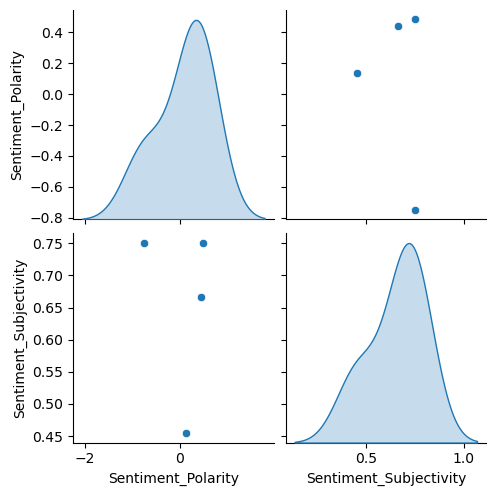

In [37]:
sns.pairplot(data=df[['Sentiment_Polarity', 'Sentiment_Subjectivity']],diag_kind='kde')
plt.show()